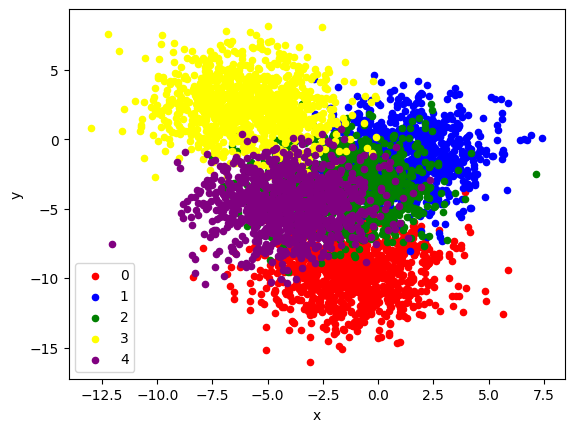

Original data shape: (55000, 2), (55000,)
Training data shape: (5000, 2), (5000,)
New data shape: (50000, 2), (50000,)


In [ ]:
#Create 2d classification dataset using make_blobs and convert X and y into pandas’s dataframe and 
# then convert y to categorical.

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from pandas import DataFrame


dataX, datay = make_blobs(n_samples=55000, centers=5, n_features=2, cluster_std=2, random_state=2)
X, newX = dataX[:5000, :], dataX[5000:, :]
y, newy = datay[:5000], datay[5000:]

df = DataFrame(dict(x=X[:,0], y=X[:,1], label=y))

colors = {0:'red', 1:'blue', 2:'green', 3:'yellow', 4:'purple'}
fig, ax = plt.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
    
plt.show()

print(f"Original data shape: {dataX.shape}, {datay.shape}")
print(f"Training data shape: {X.shape}, {y.shape}")
print(f"New data shape: {newX.shape}, {newy.shape}")


In [8]:
def evaluateModel(trainX, trainy, testX, testy):
    #Convert trainy and testy into categorical
    trainy_enc = to_categorical(trainy)
    testy_enc = to_categorical(testy)
    
    # Create a model
    model = Sequential()
    model.add(Dense(50, input_dim=2, activation='relu'))
    model.add(Dense(5, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    # fit model
    model.fit(trainX, trainy_enc, epochs=50, verbose=0)
    
    # evaluate the model
    test_loss, test_acc = model.evaluate(testX, testy_enc, verbose=0)
    
    # return the model and accuracy of test data
    return model, test_acc
    pass

In [9]:
# Create a function to make an ensemble prediction for multi-class classification

import numpy as np

def ensemblePredictions(members, testX):
    
    # make predictions
    yhats = [model.predict(testX) for model in members]
    
    yhats = np.array(yhats)
   
    # sum across ensemble members
    summed = np.sum(yhats, axis=0)
    
    # argmax across classes
    result = np.argmax(summed, axis=1)
    
    # return the result
    return result
    pass


In [10]:
# Create a function to evaluate a specific number of model in an ensemble

from sklearn.metrics import accuracy_score

def evaluateNMembers(members, n_members, testX, testy):
    
    # select a subset of members
    subset = members[:n_members]
    
    # make prediction
    yhat = ensemblePredictions(subset, testX)
    
    # calculate accuracy
    return accuracy_score(testy, yhat)
    pass

In [11]:
# creating an ensemble of 10 members and evaluating on the test dataset

from sklearn.utils import resample
from tensorflow.keras.utils import to_categorical

n_splits = 10
scores, members = list(), list()
for m in range(n_splits):
    
    # select indexes
    ix = [i for i in range(len(X))]
    train_ix = resample(ix, replace=True, n_samples=4500)
    test_ix = [x for x in ix if x not in train_ix]
    
    # select data
    trainX, trainy = X[train_ix], y[train_ix]
    testX, testy = X[test_ix], y[test_ix]
    
    # evaluate model
    model, test_acc = evaluateModel(trainX, trainy, testX, testy)
    print(f'test_acc: {test_acc:.2f}')
    
    scores.append(test_acc)
    members.append(model)

c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


test_acc: 0.78
test_acc: 0.77
test_acc: 0.76
test_acc: 0.76
test_acc: 0.76
test_acc: 0.76
test_acc: 0.78
test_acc: 0.77
test_acc: 0.76
test_acc: 0.78


In [12]:
# Evaluate different numbers of ensembles.

single_scores, ensemble_scores = list(), list()
for i in range(1, n_splits+1):
    ensemble_score = evaluateNMembers(members, i, newX, newy)
    
    newy_enc = to_categorical(newy)
    
    _, single_score = members[i-1].evaluate(newX, newy_enc, verbose=0)
    
    print(f'{i}: single={single_score: .2f}, ensemble={ensemble_score: .2f}')
    
    ensemble_scores.append(ensemble_score)
    single_scores.append(single_score)
    pass

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1: single= 0.76, ensemble= 0.76
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
2: single= 0.76, ensemble= 0.76
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
3: single= 0.76, ensemble= 0.76
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
4: single= 0.76, ensemble= 0.76
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
5: single= 0.76, ensemble= 0.76
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 973us/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1563/1563 ━━━━━━━━━━━

Accuracy  0.76 ( 0.001)


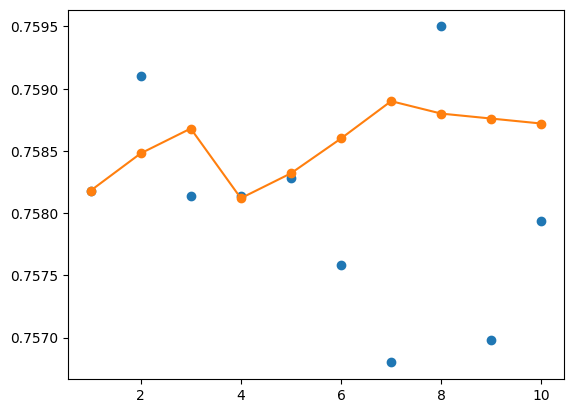

In [13]:
#Plot score vs number of ensemble members

print(f'Accuracy {np.mean(single_scores): .2f} ({np.std(single_scores): .3f})')
x_axis = [i for i in range(1, n_splits+1)]
plt.plot(x_axis, single_scores, marker='o', linestyle='None')
plt.plot(x_axis, ensemble_scores, marker='o')
plt.show()

The plot says it all. we do not make neccesarily better results from ensemble learning but we decrease the variance and make more stable models when using several classifiers.